### We will be working on the Tinatic dataset from kaggle. 
### We will be trying to predict a classification for survival and deceased.
### For this task we will be using a 'semi-cleaned' dataset.

# Importing Libraries

In [1]:
# Importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Loading the dataset

In [2]:
# Analyzing the train data
train = pd.read_csv('/home/kinjal/Documents/Task 5/titanic/train.csv')

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# EDA

In [4]:
# Exploratory Data Analysis
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
train.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<AxesSubplot: >

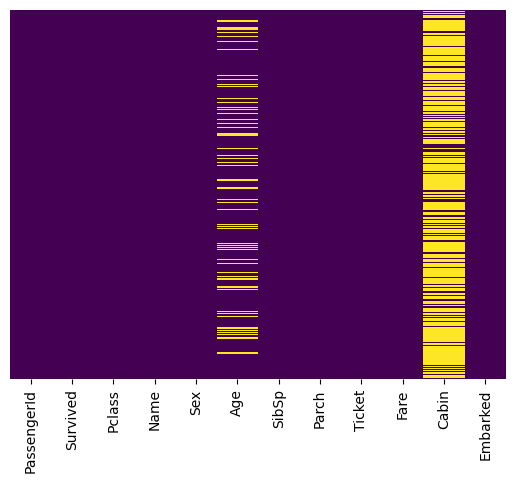

In [8]:
# Visualising the null values

sns.heatmap(train.isnull(), cbar = False, yticklabels = False, cmap = 'viridis')

#### By looking at the heatmap, we can assume that nearly 20% of the 'Age' values are missing which is small enough for reasonable replacement with some form of imputation.

#### But, if we look at the 'Cabin' column, too much information is missing to do something at the basic level. Hence, either we will be dropping the entire column or labeling as 'Cabin known: 1 0r 0' depending on the situation.

# Handling missing values and Outliers

In [9]:
train.drop(columns = ['Cabin'], inplace = True) #Dropped the cabin column

In [10]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [11]:
# Imputing missing values for Age using mean.

train['Age'].fillna(train['Age'].mean(), inplace = True)

In [12]:
# Imputing the missing values for Embarked using mode

train['Embarked'].fillna('S', inplace = True)

# Changing the data type for various columns

### 1. Survived (Category)
### 2. Pclass (Category)
### 3. Sex (Category)
### 4. Age (Int)
### 5. Embarked (Category)

In [13]:
train['Survived']=train['Survived'].astype('category')
train['Pclass']=train['Pclass'].astype('category')
train['Sex']=train['Sex'].astype('category')
train['Age']=train['Age'].astype('int')
train['Embarked']=train['Embarked'].astype('category')

In [14]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    int64   
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
dtypes: category(4), float64(1), int64(4), object(2)
memory usage: 52.8+ KB


In [15]:
train.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,29.544332,0.523008,0.381594,32.204208
std,257.353842,13.013778,1.102743,0.806057,49.693429
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,29.000000,0.000000,0.000000,14.454200
75%,668.500000,35.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


# Counting unique values in columns

In [16]:
train['Pclass'].value_counts(ascending=True)

Pclass
2    184
1    216
3    491
Name: count, dtype: int64

In [17]:
train['Sex'].value_counts(ascending=True)

Sex
female    314
male      577
Name: count, dtype: int64

In [18]:
train['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [19]:
train['Ticket'].value_counts(ascending=True)

Ticket
A/5 21171    1
3101296      1
29104        1
2641         1
2690         1
            ..
3101295      6
347088       6
CA. 2343     7
347082       7
1601         7
Name: count, Length: 681, dtype: int64

In [20]:
train['Embarked'].value_counts(dropna=False)

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [21]:
train['Fare'].value_counts(bins = 7)

(-0.513, 73.19]       789
(73.19, 146.38]        71
(146.38, 219.57]       15
(219.57, 292.76]       13
(439.139, 512.329]      3
(292.76, 365.949]       0
(365.949, 439.139]      0
Name: count, dtype: int64

# Visualisation of train data and Univariate Analysis

Out of 891, 62% people died in the accident


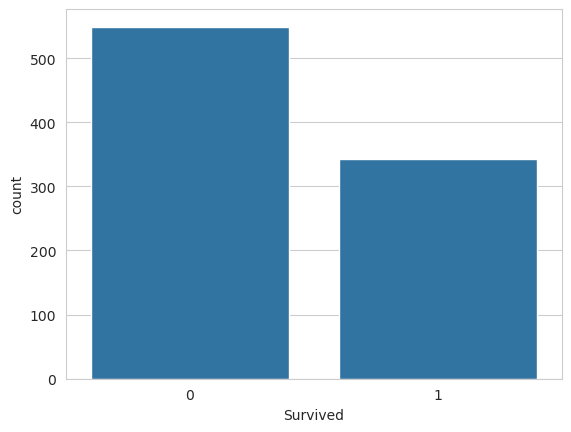

In [22]:
# Target Column

sns.set_style('whitegrid')
sns.countplot(x = 'Survived', data = train)

death_percent = round((train['Survived'].value_counts().values[0]/891)*100)

print('Out of 891, {}% people died in the accident'.format(death_percent))

### Out of 891 passengers, 62% people died in the accident.

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: count, dtype: float64


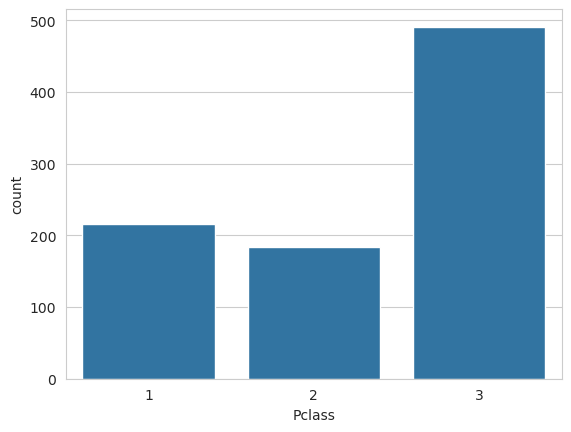

In [23]:
# Pclass Column

sns.set_style('whitegrid')
sns.countplot(x = 'Pclass', data = train)

print((train['Pclass'].value_counts()/891)*100)

### We can conclude that the 'Class 3' among the Pclass was the most crowded.

Sex
male      64.758698
female    35.241302
Name: count, dtype: float64


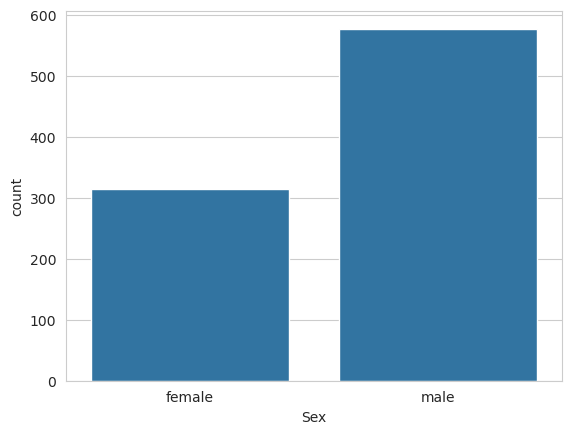

In [24]:
# Sex column

sns.set_style('whitegrid')
sns.countplot(x = 'Sex', data = train)

print((train['Sex'].value_counts()/891)*100)

### We can conclude that most of the passengers travelling in the ship were Male.

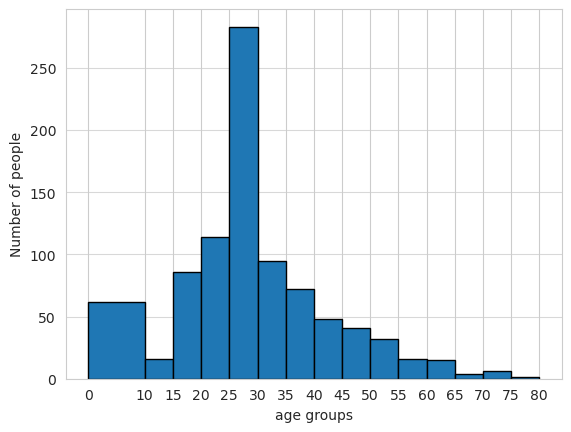

In [25]:
# Age Column (Histogram)

bins=[0,10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80]
ages = train['Age']

plt.hist(ages, bins = bins, edgecolor='black')
plt.xlabel('age groups')
plt.ylabel('Number of people')
plt.xticks(bins)
plt.grid(axis='y', alpha=0.75)
plt.show()

### We can conclude that most of the passengers on board were between the age groups of '25-30'

0.45956263424701577
0.9865867453652877


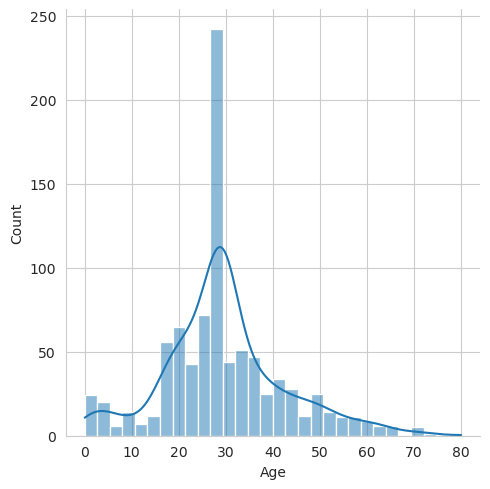

In [26]:
# Age Column (Displot)


sns.displot(train['Age'], kde = True)

print(train['Age'].skew())
print(train['Age'].kurt())

### The skewness of the data (0.46) signifies that the age column follows a normal distribution.
### The Kurtosis of the data (0.98) is not too high, which signifies the existence of normal distribution.
### We can conclude that most of the passengers on board were between the age groups of '20-40'.

<AxesSubplot: xlabel='Age'>

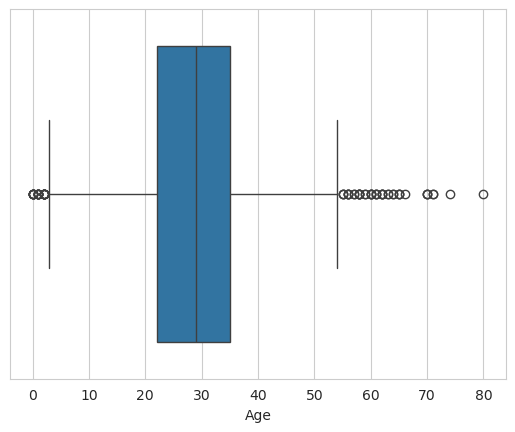

In [27]:
# Age Column (Box plot)

sns.boxplot(x = 'Age', data = train)

### The inter-quartile range between the ages is between '20-40' which indicates the most number of passengers between this age group.
### The ages after 55 are considered as outliers.

Parch
0    76.094276
1    13.243547
2     8.978676
5     0.561167
3     0.561167
4     0.448934
6     0.112233
Name: count, dtype: float64


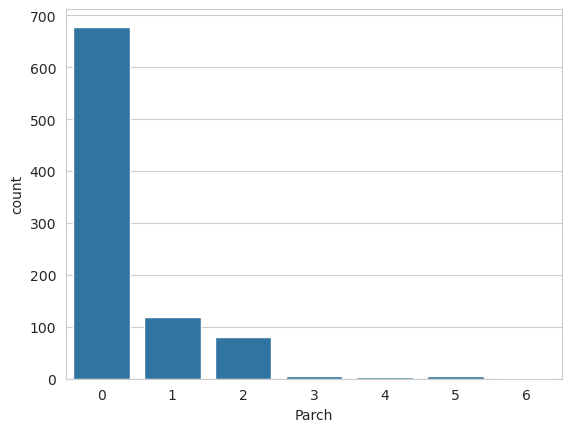

In [28]:
# Parch Column

sns.set_style('whitegrid')
sns.countplot(x = 'Parch', data = train)

print((train['Parch'].value_counts()/891)*100)

### Around 76 % of the total passengers were travelling alone.

Embarked
S    72.502806
C    18.855219
Q     8.641975
Name: count, dtype: float64


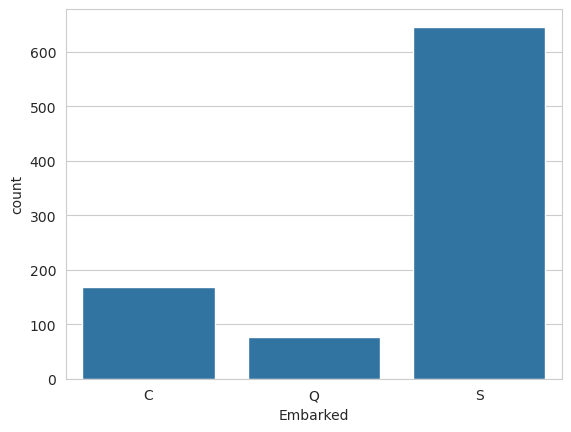

In [29]:
# Embarked Column

sns.set_style('whitegrid')
sns.countplot(x = 'Embarked', data = train)

print((train['Embarked'].value_counts()/891)*100)

### Around 73 % of the travellers were destined to go to the city starting with letter 'S'.

# Finding the number of passengers in different age groups.

In [30]:
print('Number of people between age group 0 to 10: ', train[(train['Age']> 0) & (train['Age']<= 10)].shape[0])
print('Number of people between age group 10 to 20: ', train[(train['Age']> 10) & (train['Age']<= 20)].shape[0])
print('Number of people between age group 20 to 30: ', train[(train['Age']> 20) & (train['Age']<= 30)].shape[0])
print('Number of people between age group 30 to 40: ', train[(train['Age']> 30) & (train['Age']<= 40)].shape[0])
print('Number of people between age group 40 to 50: ', train[(train['Age']> 40) & (train['Age']<= 50)].shape[0])
print('Number of people between age group 50 to 60: ', train[(train['Age']> 50) & (train['Age']<= 60)].shape[0])
print('Number of people between age group 60 to 70: ', train[(train['Age']> 60) & (train['Age']<= 70)].shape[0])
print('Number of people between age group 70 to 80: ', train[(train['Age']> 70) & (train['Age']<= 80)].shape[0])

Number of people between age group 0 to 10:  57
Number of people between age group 10 to 20:  116
Number of people between age group 20 to 30:  408
Number of people between age group 30 to 40:  155
Number of people between age group 40 to 50:  84
Number of people between age group 50 to 60:  42
Number of people between age group 60 to 70:  18
Number of people between age group 70 to 80:  4


### For all practical purposes, age can be considered as a normal distribution.

4.787316519674893
33.39814088089868


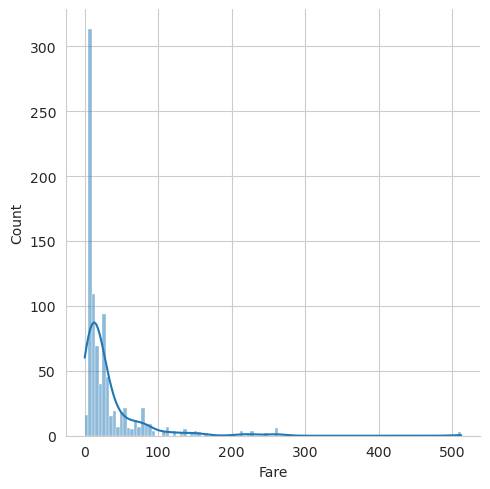

In [31]:
# Fare Column (Displot)

sns.displot(train['Fare'], kde=True)

print(train['Fare'].skew())
print(train['Fare'].kurt())

### The Fare column is positively skewed, which indicates the Ticket Fare was mostly between '1 to 60' dollars.
### The Kurtosis is extremely high, which indicates the positive skewness of the Fare column.
### Nearly 94 % of the total bought cheap tickets.

<AxesSubplot: xlabel='Fare'>

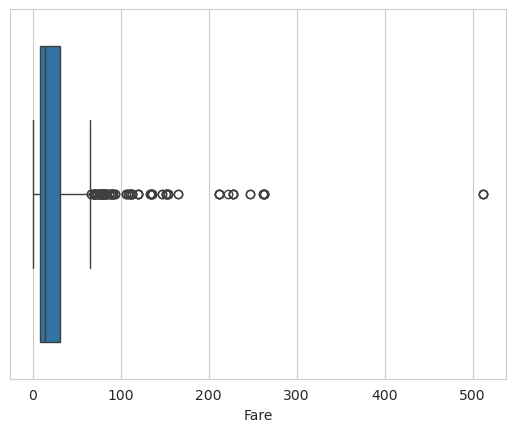

In [32]:
# Fare Column (Box plot)

sns.boxplot(x = 'Fare', data = train)

### The inter-quartile range between the fares is between '1-100' which indicates the most number of passengers were in this range.
### The fares after 100 dollars are considered as outliers.
### Nearly 94 % of the total bought cheap tickets.

# Finding the number of people in different ticket fares

In [33]:
print('Number of people with fare in between $1 to $100: ', train[(train['Fare'] >= 0) & (train['Fare'] < 100)].shape[0])
print('Number of people with fare in between $100 to $200: ', train[(train['Fare'] >100) & (train['Fare'] <= 200)].shape[0])
print('Number of people with fare in between $200 to $300: ', train[(train['Fare'] > 200) & (train['Fare'] <= 300)].shape[0])
print('Number of people with fare in between $300 to $400: ', train[(train['Fare'] > 300) & (train['Fare'] <= 400)].shape[0])
print('Number of people with fare in between $400 to $500: ', train[(train['Fare'] > 400) & (train['Fare'] <= 500)].shape[0])
print('Number of people with fare greater than $500: ', train[(train['Fare'] > 500)].shape[0])

Number of people with fare in between $1 to $100:  838
Number of people with fare in between $100 to $200:  33
Number of people with fare in between $200 to $300:  17
Number of people with fare in between $300 to $400:  0
Number of people with fare in between $400 to $500:  0
Number of people with fare greater than $500:  3


# Multivariate Analysis

Survived,0,1
Pclass,,
1,37.0,63.0
2,52.7,47.3
3,75.8,24.2


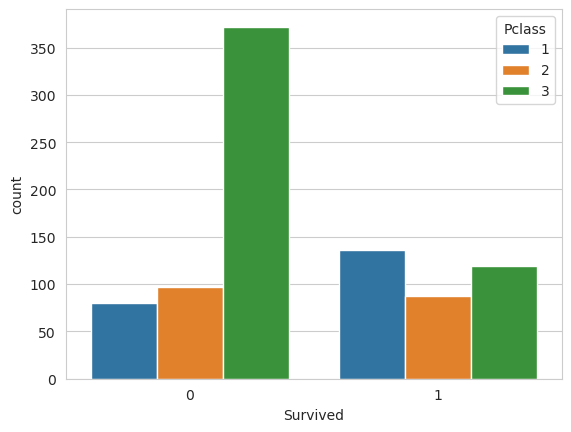

In [34]:
# Survival with Pclass

sns.countplot(x = 'Survived', hue = 'Pclass', data = train)

pd.crosstab(train['Pclass'], train['Survived']).apply(lambda r: round((r/r.sum())*100,1), axis = 1)

### It shows that nearly 79% of the people in 'Class 3' of the ship were deceased.
### Out of the number of people survived, 63% were from 'Class 1' of the ship.

Survived,0,1
Sex,,
female,25.8,74.2
male,81.1,18.9


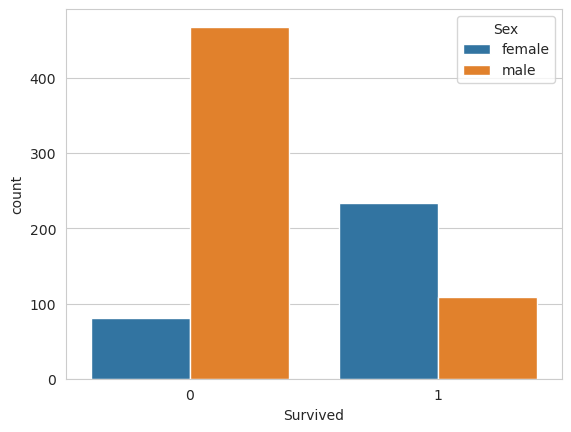

In [35]:
# Survival with Sex

sns.countplot(x = 'Survived', hue = 'Sex', data = train)

pd.crosstab(train['Sex'], train['Survived']).apply(lambda r: round((r/r.sum())*100,1), axis = 1)

### We can conclude that nearly 81% of the total number of 'Male' polpulation were deceased.
### Nearly 74% of the 'Female' population survived.

Survived,0,1
Embarked,,
C,44.6,55.4
Q,61.0,39.0
S,66.1,33.9


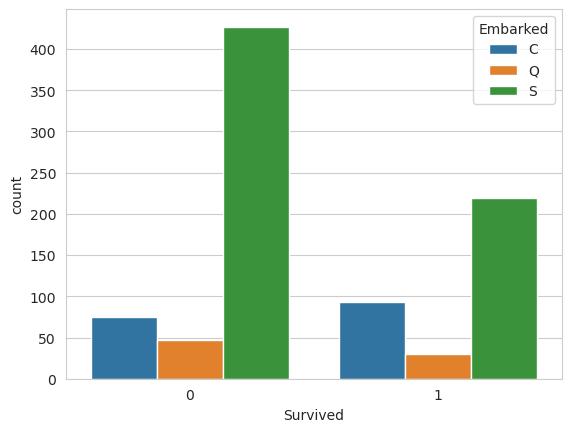

In [36]:
# Survival with Embarked

sns.countplot(x = 'Survived', hue = 'Embarked', data = train)

pd.crosstab(train['Embarked'], train['Survived']).apply(lambda r: round((r/r.sum())*100,1), axis = 1)

### Around 61% of the people whose destination was 'S', were deceased.
### Around 55% of the people whose destination was 'C', survived.

/tmp/ipykernel_24251/3903846405.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train[train['Survived']==0]['Age'])
/tmp/ipykernel_24251/3903846405.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train[train['Survived']==1]['Age'])


<AxesSubplot: xlabel='Age', ylabel='Density'>

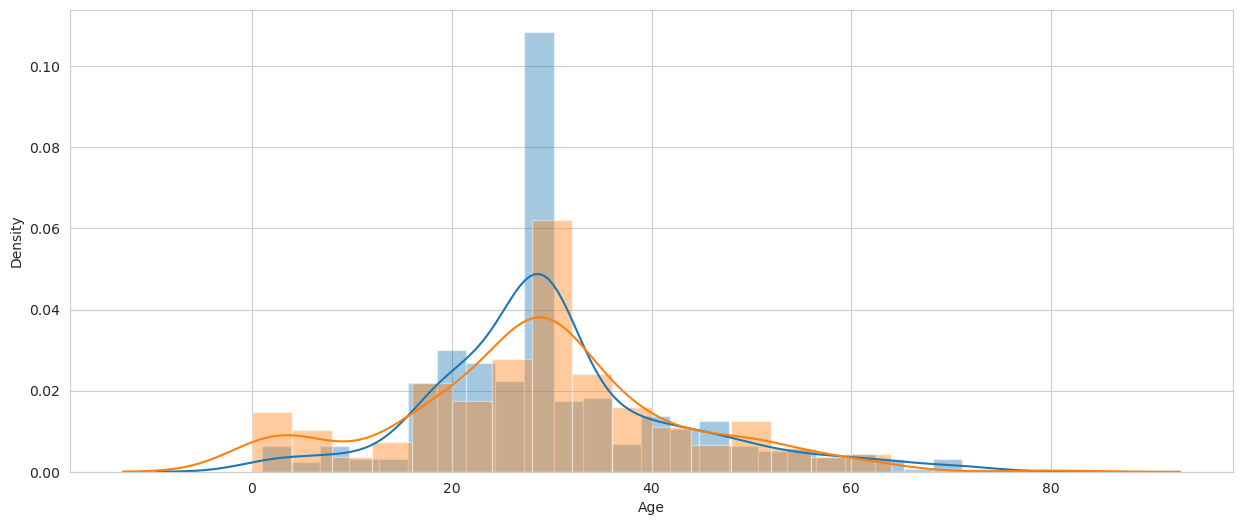

In [37]:
# Survival with Age

plt.figure(figsize=(15,6))
sns.distplot(train[train['Survived']==0]['Age'])
sns.distplot(train[train['Survived']==1]['Age'])

### Here, the blue curve represents the deceased, and orange represents survived ones. 
### The age groups from '0-15' years had more rate of survival.
### The age groups from '15-45' years had more rate of deceased.

/tmp/ipykernel_24251/3238617403.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train[train['Survived']==0]['Fare'])
/tmp/ipykernel_24251/3238617403.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train[train['Survived']==1]['Fare'])


<AxesSubplot: xlabel='Fare', ylabel='Density'>

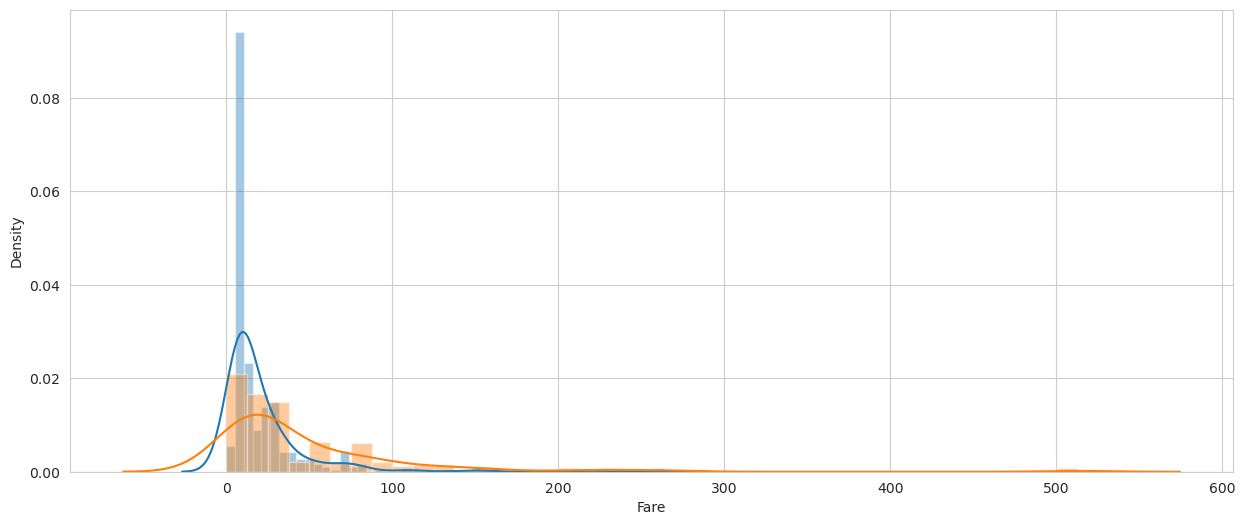

In [38]:
# Survival with Fare

plt.figure(figsize=(15,6))
sns.distplot(train[train['Survived']==0]['Fare'])
sns.distplot(train[train['Survived']==1]['Fare'])

### The rate of deceased was more than the rate of survival among the people who had bought tickets in between '0-100' dollars.

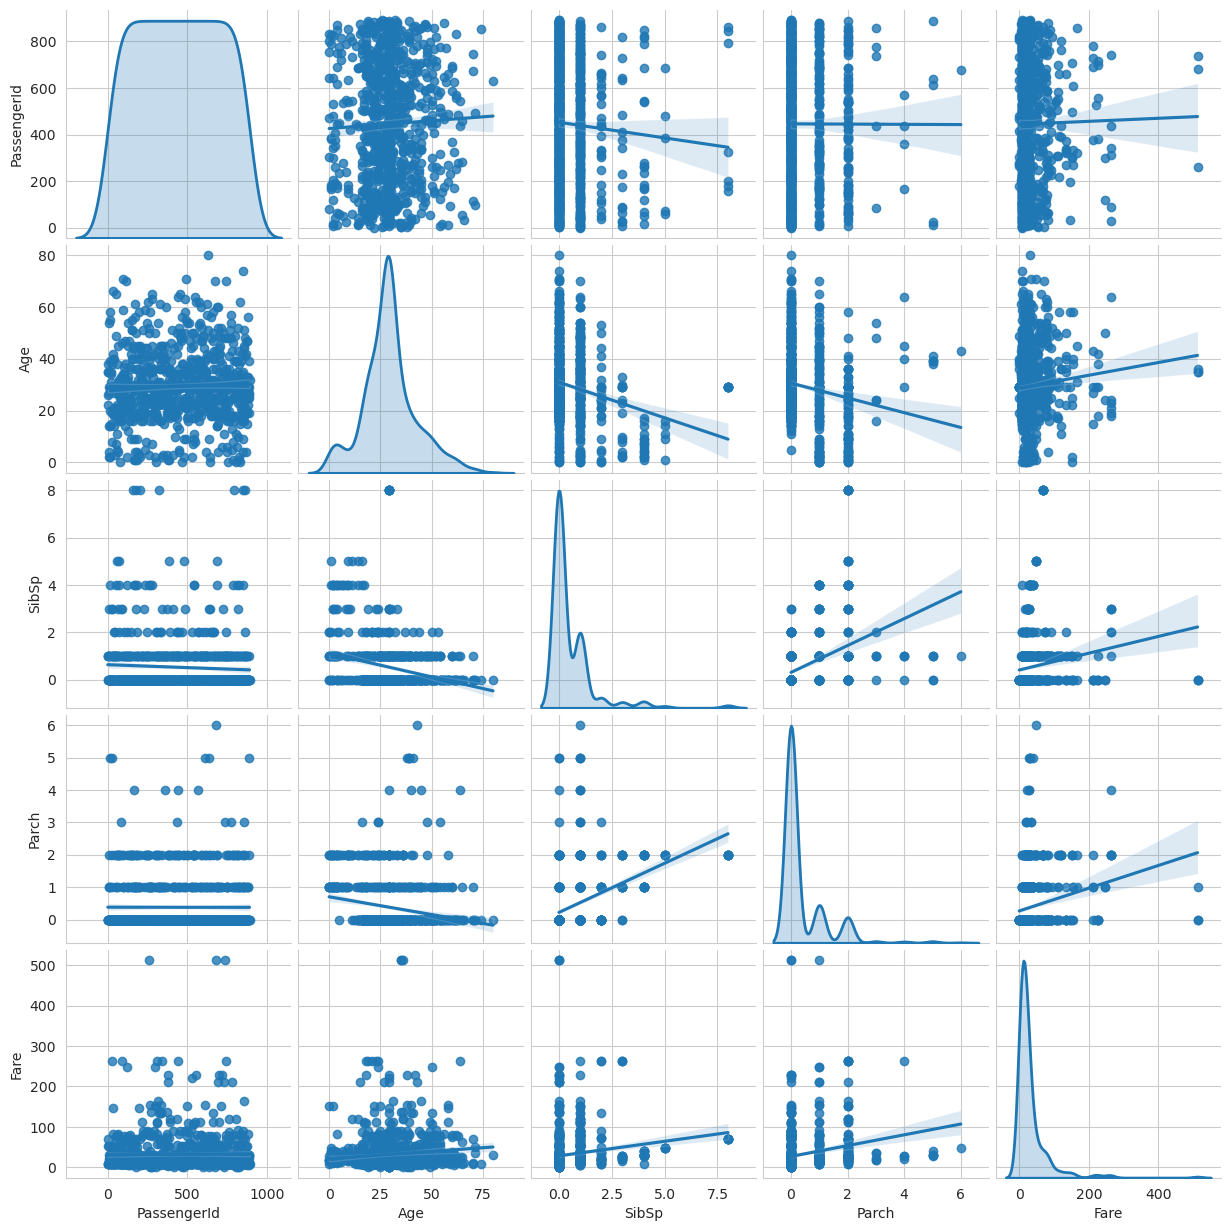

In [39]:
# Using Pairplot

sns.pairplot(train, diag_kind='kde', diag_kws={'linewidth':2}, kind = 'reg')

In [40]:
# Using Heatmap

'''sns.heatmap(train.corr(), cbar=True, cmap='viridis')
plt.title("Heatmap between correlation of numerical values")
plt.show()'''

'sns.heatmap(train.corr(), cbar=True, cmap=\'viridis\')\nplt.title("Heatmap between correlation of numerical values")\nplt.show()'

In [41]:
# Feature Engineering

train['family_size'] = train['Parch'] + train['SibSp']
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,family_size
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S,0


In [42]:
# New feature
def family_type(number):
    if number == 0:
        return 'Alone'
    elif number > 0 and  number <= 4:
        return 'Medium'
    else:
        return 'Large'

In [43]:
train['family_type']=train['family_size'].apply(family_type)
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,family_size,family_type
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S,1,Medium
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C,1,Medium
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S,0,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S,1,Medium
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S,0,Alone


In [44]:
train.drop(columns = ['SibSp','Parch','family_size'], inplace = True)
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,family_type
0,1,0,3,"Braund, Mr. Owen Harris",male,22,A/5 21171,7.2500,S,Medium
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,PC 17599,71.2833,C,Medium
2,3,1,3,"Heikkinen, Miss. Laina",female,26,STON/O2. 3101282,7.9250,S,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,113803,53.1000,S,Medium
4,5,0,3,"Allen, Mr. William Henry",male,35,373450,8.0500,S,Alone


In [45]:
pd.crosstab(train['family_type'], train['Survived']).apply(lambda r: round((r/r.sum())*100,1), axis = 1)

Survived,0,1
family_type,,
Alone,69.6,30.4
Large,85.1,14.9
Medium,44.0,56.0


### Nearly 70% of the passengers travelling alone were deceased.
### Nearly 85% of the passengers having large family were deceased.
### Nearly 56% of the passengers having medium family size survived.

# Summary of findings

#### 1. Out of 891 passengers, 62% people died in the accident.
#### 2. Nearly 79% of the people in 'Class 3' of the ship were deceased.
#### 3. Out of the number of people survived, 63% were from 'Class 1' of the ship.
#### 4.We can conclude that nearly 81% of the total number of 'Male' polpulation were deceased. Nearly 74% of the 'Female' population survived.
#### 5. Around 61% of the people whose destination was 'S', were deceased. Around 55% of the people whose destination was 'C', survived.
#### 6. The age groups from '0-15' years had more rate of survival. The age groups from '15-45' years had more rate of deceased.
#### 7. The rate of deceased was more than the rate of survival among the people who had bought tickets in between '0-100' dollars.
#### 8. Nearly 70% of the passengers travelling alone were deceased. Nearly 85% of the passengers having large family were deceased. Nearly 56% of the passengers having medium family size survived.